Setup
---

Make sure to select GPU in Runtime > Change runtime type > Hardware accelerator

In [0]:
import sys

# Checks that the Runtime is correct
if 'google.colab' in sys.modules:
    !nvidia-smi | grep -q 'failed' && echo "STOP! You are using a runtime without a GPU. Change the runtime type before going further!"

In [0]:
import sys

# Setup for use in Colab
if 'google.colab' in sys.modules:
    # Clone GitHub repository
    !git clone https://github.com/MasterScrat/droneRL-workshop.git --single-branch
        
    # Install packages with uv
    !pip install uv
    !uv pip install --system -r droneRL-workshop/pyproject.toml
    
    # Restart Runtime so everything takes effect
    import os
    os.kill(os.getpid(), 9)

    # Your Runtime will crash after this - this is normal!
    # Resume from next cell after it restarted

fatal: destination path 'droneRL-workshop' already exists and is not an empty directory.
     |████████████████████████████████| 1.6MB 2.7MB/s 
     |████████████████████████████████| 61kB 9.5MB/s 
     |████████████████████████████████| 225kB 18.6MB/s 
     |████████████████████████████████| 13.1MB 232kB/s 
     |████████████████████████████████| 1.0MB 70.1MB/s 
  Created wheel for gym: filename=gym-0.15.4-cp36-none-any.whl size=1648483 sha256=c5abc024eb82019c7088a429099571e0046a4d0f1329083ab1348d0f8b892ad7
  Stored in directory: /root/.cache/pip/wheels/e9/26/9b/8a1a6599a91077a938ac4348cc3d3ac84bfab0dbfddeb4c6e7
Successfully built gym
ERROR: albumentations 0.1.12 has requirement imgaug<0.2.7,>=0.2.5, but you'll have imgaug 0.2.9 which is incompatible.
  Found existing installation: pyglet 1.4.10
    Uninstalling pyglet-1.4.10:
      Successfully uninstalled pyglet-1.4.10
  Found existing installation: gym 0.15.6
    Uninstalling gym-0.15.6:
      Successfully uninstalled gym-0.15.6
  

In [2]:
%cd droneRL-workshop

/content/droneRL-workshop


Training multiple agents at once
---

In [0]:
import datetime
import os
import numpy as np

from agents.dqn import DQNAgent, ConvQNetworkFactory, ConvQNetwork
from agents.random import RandomAgent
from agents.logging import TensorBoardLogger, NoLogger
from env.env import DeliveryDrones
from env.wrappers import WindowedGridView
from helpers.rl_helpers import MultiAgentTrainer, test_agents, plot_cumulative_rewards, plot_rolling_rewards, render_video, render_html, ColabHTML

In [0]:
env = WindowedGridView(DeliveryDrones(), radius=3)

# Default parameters used for evaluation
env.env_params.update({
    'charge': 20,
    'charge_reward': -0.1,
    'crash_reward': -1,
    'delivery_reward': 1,
    'discharge': 10,
    'drone_density': 0.05,
    'dropzones_factor': 2,
    'n_drones': 10,
    'packets_factor': 3,
    'pickup_reward': 0,
    'rgb_render_rescale': 1.0,
    'skyscrapers_factor': 3,
    'stations_factor': 2
})

In [0]:
# Setup Tensorboard - wait a bit after running this
%load_ext tensorboard

In [11]:
# Show Tensorboard. It will initially be empty
%tensorboard --logdir logs

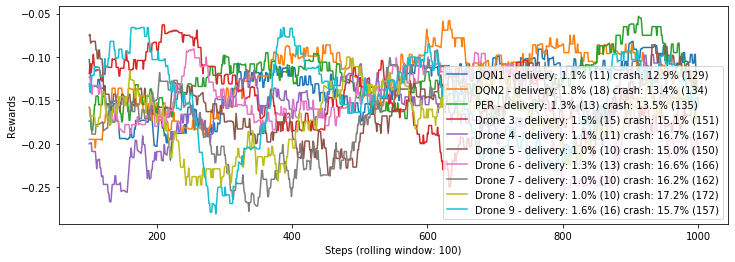

In [15]:
# Setup TensorBoard loggers
tb_logger_1 = TensorBoardLogger(os.path.join('logs', 'dqn1'), datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S'))
tb_logger_2 = TensorBoardLogger(os.path.join('logs', 'dqn2'), datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S'))
tb_logger_3 = TensorBoardLogger(os.path.join('logs', 'dqn3'), datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S'))

# Create 3 DQN agents with different hyper-parameters and TensorBoard logging
dqn_agent_1 = DQNAgent(
    env, ConvQNetworkFactory(env, conv_layers=[
        {'out_channels': 32, 'kernel_size': 3, 'stride': 2, 'padding': 1},
        {'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
        {'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
        {'out_channels': 32, 'kernel_size': 3, 'stride': 1, 'padding': 1},
    ], dense_layers=[256]),
    gamma=0.95, epsilon_start=1, epsilon_decay=0.99, epsilon_end=0.01, memory_size=10000, batch_size=64, 
    target_update_interval=500, logger=tb_logger_1)

dqn_agent_2 = DQNAgent(
    env, ConvQNetworkFactory(env, conv_layers=[
        {'out_channels': 32, 'kernel_size': 3, 'stride': 2, 'padding': 1},
        {'out_channels': 64, 'kernel_size': 3, 'stride': 1, 'padding': 1}
    ], dense_layers=[64, 64]),
    gamma=0.99, epsilon_start=1, epsilon_decay=0.99, epsilon_end=0.01, memory_size=10000, batch_size=64, 
    target_update_interval=500, logger=tb_logger_2)

dqn_agent_3 = DQNAgent(
    env, ConvQNetworkFactory(env, conv_layers=[
        {'out_channels': 64, 'kernel_size': 3, 'stride': 1, 'padding': 1}
    ], dense_layers=[16, 16]),
    gamma=0.99, epsilon_start=1, epsilon_decay=0.99, epsilon_end=0.01, memory_size=10000, batch_size=64, 
    target_update_interval=500, logger=tb_logger_3)

# Reset environment with those parameters
env.reset()

# Setup random opponents
agents = {drone.index: RandomAgent(env) for drone in env.drones}

# Add the RL drones
agents[0] = dqn_agent_1
agents[1] = dqn_agent_2
agents[2] = dqn_agent_3

# Create trainer
trainer = MultiAgentTrainer(env, agents, reset_agents=True, seed=0)

# Let's train!
trainer.train(1000)
rewards = plot_rolling_rewards(trainer.rewards_log, drones_labels={0: 'DQN1', 1: 'DQN2', 2: 'PER'})



In [13]:
trainer.train(5000)

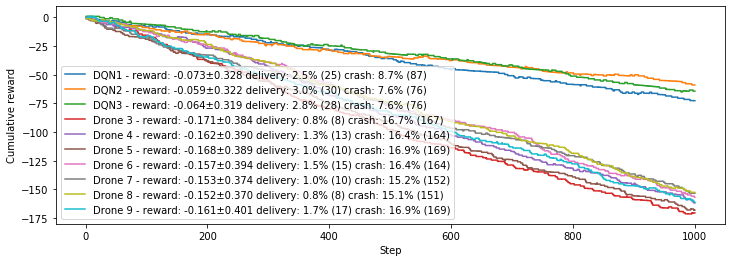

Agent 0: -72.6
Agent 1: -58.900000000000006
Agent 2: -64.30000000000001
Agent 3: -170.5
Agent 4: -161.7
Agent 5: -168.1
Agent 6: -156.8
Agent 7: -153.29999999999998
Agent 8: -152.5
Agent 9: -161.20000000000002


In [14]:
# Evaluation
rewards_log = test_agents(env, agents, n_steps=1000)
plot_cumulative_rewards(rewards_log, drones_labels={0: 'DQN1', 1: 'DQN2', 2: 'DQN3'})

# Print final evaluation scores
print('Final scores:')
for idx, score in enumerate(np.sum(list(rewards_log.values()), axis=1)):
    print("Agent {}: {}".format(idx, score))

In [0]:
# Save the agent (you can ignore the warnings)
per_agent_1.save('dqn-agent-0.pt')

**Experiment a bit then submit to AIcrowd :D**

> https://www.aicrowd.com/challenges/droneracer